Versuch 41

Auftragen der Druckwerte gegen Temperatur

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import uncertainties as unc
import uncertainties.unumpy as unp


In [49]:
T = np.array([0, 100])
p_0 = 906
p_0_error = 2.1
p_100 = 1250
p_100_error = 4

p_stickstoff = 250
p_stickstoff_error = 2.1


In [50]:
func = lambda T, m, c: m * T + c

popt, pcov = curve_fit(func, T, [p_0, p_100], sigma=[p_0_error, p_100_error])

m, c = popt
print(f"fitted func: p(T) = {m} * T + {c}")
print(f"covariance matrix: {pcov}")

fitted func: p(T) = 3.440000000000001 * T + 906.0
covariance matrix: [[inf inf]
 [inf inf]]


/var/folders/9r/ppvq7f7j3kv69gnk_v549lcm0000gn/T/ipykernel_3698/1421784858.py:3: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func, T, [p_0, p_100], sigma=[p_0_error, p_100_error])


T = (0 - c)/m (bei 0mbar)

In [51]:
temp = (0-c)/m
print(f"temperatur (0mbar) = {temp} C")

temperatur (0mbar) = -263.37209302325573 C


T stickstoff = (p_stickstoff - c)/m

In [52]:
temp_n2 = (p_stickstoff-c)/m
print(f"temperatur (Stickstoff) = {temp_n2} C")

temperatur (Stickstoff) = -190.6976744186046 C


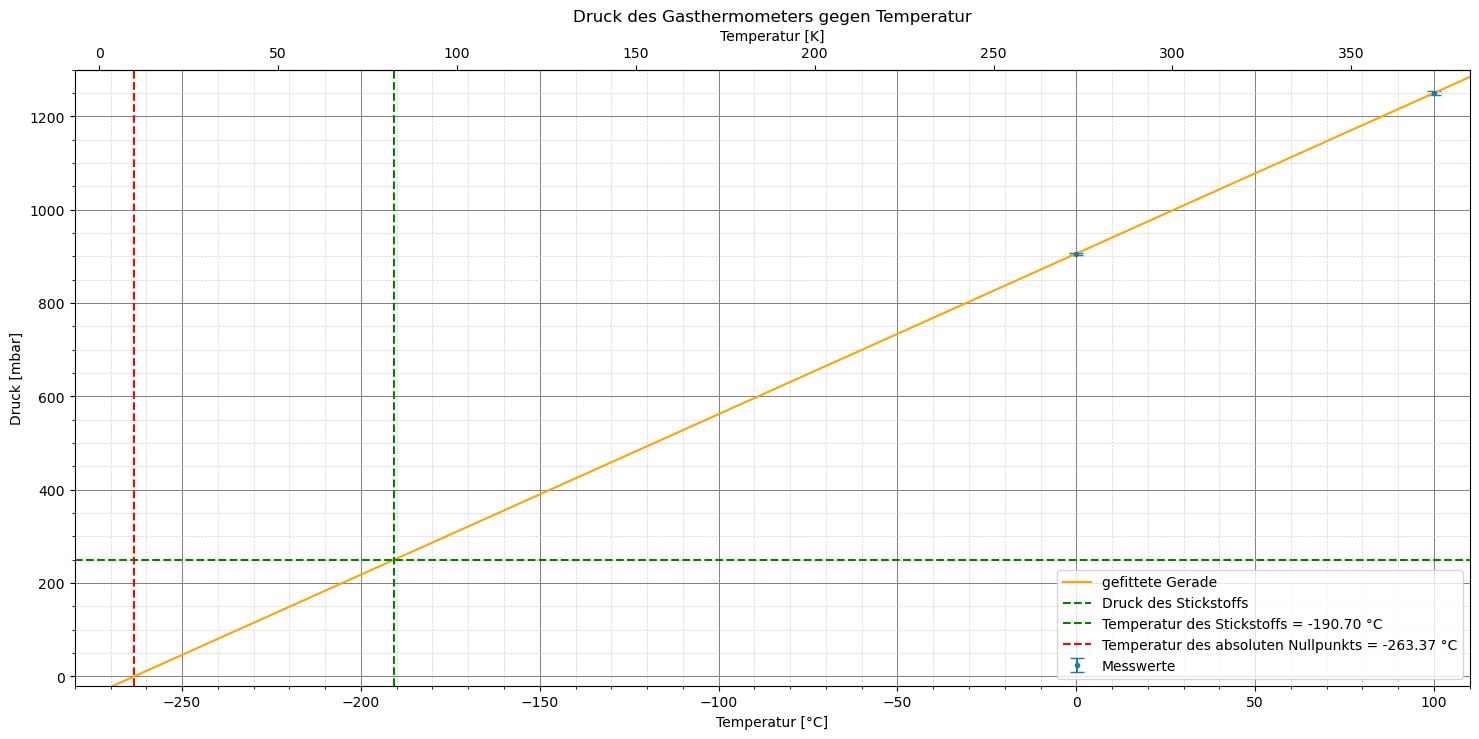

In [53]:
fig, ax = plt.subplots(figsize=(18, 8))

ax.errorbar(
    T, 
    [p_0, p_100],
    yerr=[p_0_error, p_100_error],
    fmt='.',
    capsize=5,
    label='Messwerte'
)

ax.plot(
    np.linspace(-280, 110, 100),
    func(np.linspace(-280, 110, 100), *popt),
    label='gefittete Gerade',
    color='orange'
)

ax.axhline(p_stickstoff,
           color='green',
           linestyle='--',
           label='Druck des Stickstoffs'
)

ax.axvline(temp_n2,
           color='green',
           linestyle='--',
           label=(f'Temperatur des Stickstoffs = {temp_n2:.2f} °C')
)

ax.axvline(temp,
           color='red',
           linestyle='--',
           label=(f'Temperatur des absoluten Nullpunkts = {temp:.2f} °C')
)


ax.set_title('Druck des Gasthermometers gegen Temperatur')
ax.set_xlabel('Temperatur [°C]')
ax.set_ylabel('Druck [mbar]')

ax.set_xlim(-280, 110)
ax.set_ylim(-20, 1300)

# Kelvin-Skala oben an der x-Achse
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x + 273.15, lambda x: x - 273.15))
ax2.set_xlabel('Temperatur [K]')
ax2.set_xlim(ax.get_xlim())

ax.minorticks_on()
ax.grid(which='major', linewidth=0.7, color='gray')
ax.grid(which='minor', linewidth=0.5, color='lightgray', linestyle='--')

ax.legend()


Eichung mit Sticksoff bei 77K

In [54]:
T_stickstoff_lit = -195.8

T_A2 = [T_stickstoff_lit, 0, 100]
p_A2 = [p_stickstoff, p_0, p_100]
popt_A2, pcov = curve_fit(func, T_A2, p_A2)

print(f"fitted func: p(T) = {popt_A2[0]} * T + {popt_A2[1]}")
print(f"Eror in m, c: {np.sqrt(np.diag(pcov))}")

c_A2 = popt_A2[1]
m_A2 = popt_A2[0]

ufloat_c_A2 = unc.ufloat(c_A2, np.sqrt(pcov[1, 1]))
ufloat_m_A2 = unc.ufloat(m_A2, np.sqrt(pcov[0, 0]))
print(ufloat_c_A2, ufloat_m_A2)


fitted func: p(T) = 3.3764777454661785 * T + 909.8221893244094
Eror in m, c: [0.02238075 2.84090528]
909.8+/-2.8 3.376+/-0.022


In [55]:
temp0_A2 = (0-ufloat_c_A2)/ufloat_m_A2
print(f"temperatur (0mbar) = {temp0_A2} C = {temp0_A2 + 273.15} K")

p_trockeneis = unc.ufloat(651, 2.1)
temp_trockeneis = (p_trockeneis-ufloat_c_A2)/ufloat_m_A2
print(f"temperatur (Trockeneis) = {temp_trockeneis} C = {temp_trockeneis + 273.15} K")

temperatur (0mbar) = -269.5+/-2.0 C = 3.7+/-2.0 K
temperatur (Trockeneis) = -76.7+/-1.2 C = 196.5+/-1.2 K


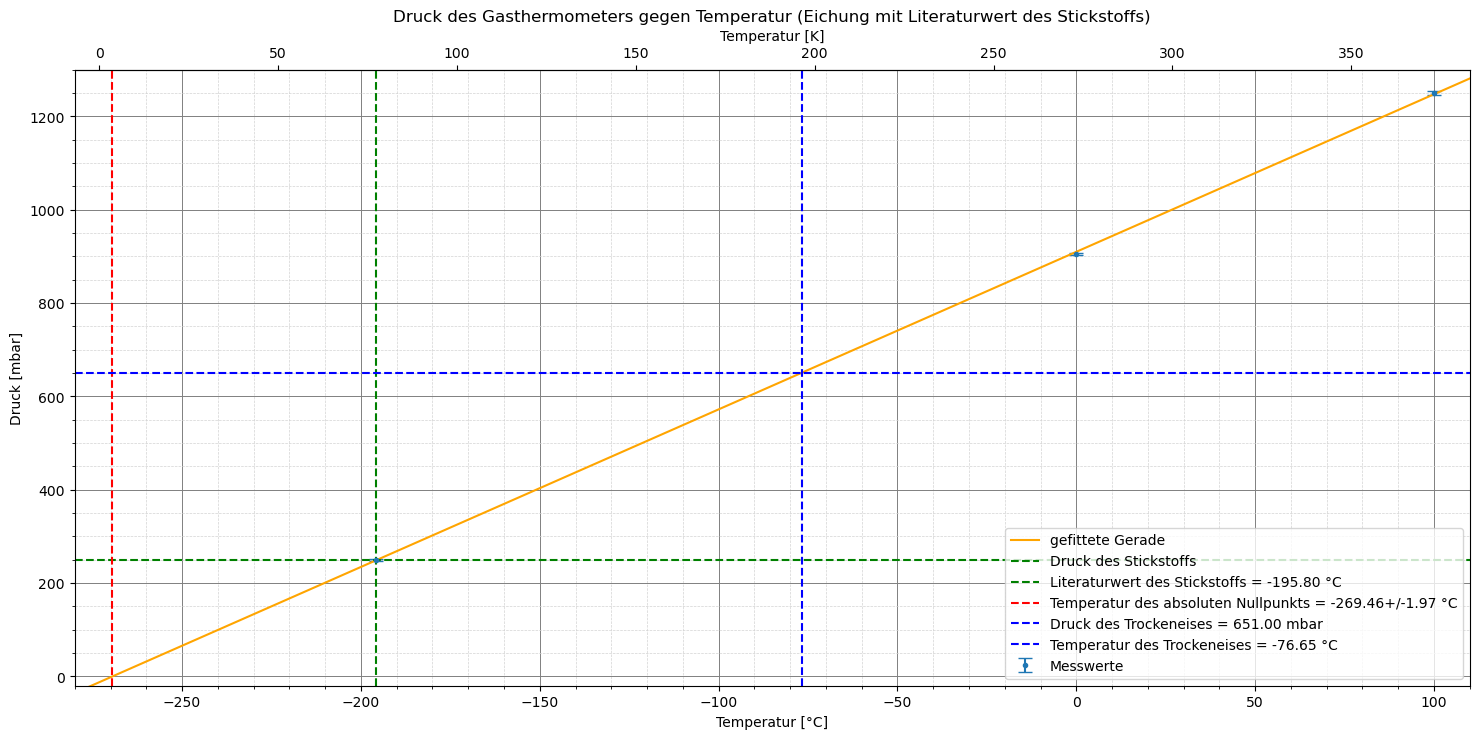

In [56]:
fig, ax = plt.subplots(figsize=(18, 8))

ax.errorbar(
    T_A2, 
    p_A2,
    yerr=[p_stickstoff_error, p_0_error, p_100_error],
    fmt='.',
    capsize=5,
    label='Messwerte'
)

ax.plot(
    np.linspace(-280, 110, 100),
    func(np.linspace(-280, 110, 100), *popt_A2),
    label='gefittete Gerade',
    color='orange'
)

ax.axhline(p_stickstoff,
           color='green',
           linestyle='--',
           label='Druck des Stickstoffs'
)

ax.axvline(T_stickstoff_lit,
           color='green',
           linestyle='--',
           label=(f'Literaturwert des Stickstoffs = {T_stickstoff_lit:.2f} °C')
)

ax.axvline(temp0_A2.n,
           color='red',
           linestyle='--',
           label=(f'Temperatur des absoluten Nullpunkts = {temp0_A2:.2f} °C')
)

# Trockeneis


ax.axhline(p_trockeneis.n,
           color='blue',
           linestyle='--',
           label=(f'Druck des Trockeneises = {p_trockeneis.n:.2f} mbar')
)

ax.axvline(temp_trockeneis.n,
           color='blue',
           linestyle='--',
           label=(f'Temperatur des Trockeneises = {temp_trockeneis.n:.2f} °C')
)

ax.set_title('Druck des Gasthermometers gegen Temperatur (Eichung mit Literaturwert des Stickstoffs)')
ax.set_xlabel('Temperatur [°C]')
ax.set_ylabel('Druck [mbar]')

ax.set_xlim(-280, 110)
ax.set_ylim(-20, 1300)

# Kelvin-Skala oben an der x-Achse
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x + 273.15, lambda x: x - 273.15))
ax2.set_xlabel('Temperatur [K]')
ax2.set_xlim(ax.get_xlim())

ax.minorticks_on()
ax.grid(which='major', linewidth=0.7, color='gray')
ax.grid(which='minor', linewidth=0.5, color='lightgray', linestyle='--')

ax.legend()


Plot A3

In [57]:

p_error = 2.1

pressure_values = [
    906.0, 950.0, 980.4, 1017.0, 1048.0, 1081.0, 
    1114.0, 1146.0, 1182.8, 1211.0, 1241.0
]

pressure_A3 = unp.uarray(pressure_values, p_error)


Temp_A3 = (pressure_A3 - ufloat_c_A2) / ufloat_m_A2

Temp_A3_values = unp.nominal_values(Temp_A3)
print(len(Temp_A3_values))
Temp_A3


11


array([-1.1320048916483039+/-1.0463271448987546,
       11.89932637036926+/-1.0492689264472357,
       20.902791605945026+/-1.0554340572034604,
       31.742489882986916+/-1.067245791779868,
       40.923655090317475+/-1.0808912920109,
       50.69715353683065+/-1.0989398638981294,
       60.47065198334382+/-1.1204487175241686,
       69.94798381026568+/-1.1444261708151038,
       80.84691541122582+/-1.175551100481099,
       89.19881408370073+/-1.2017980901395944,
       98.08381267143997+/-1.2318395116246617], dtype=object)

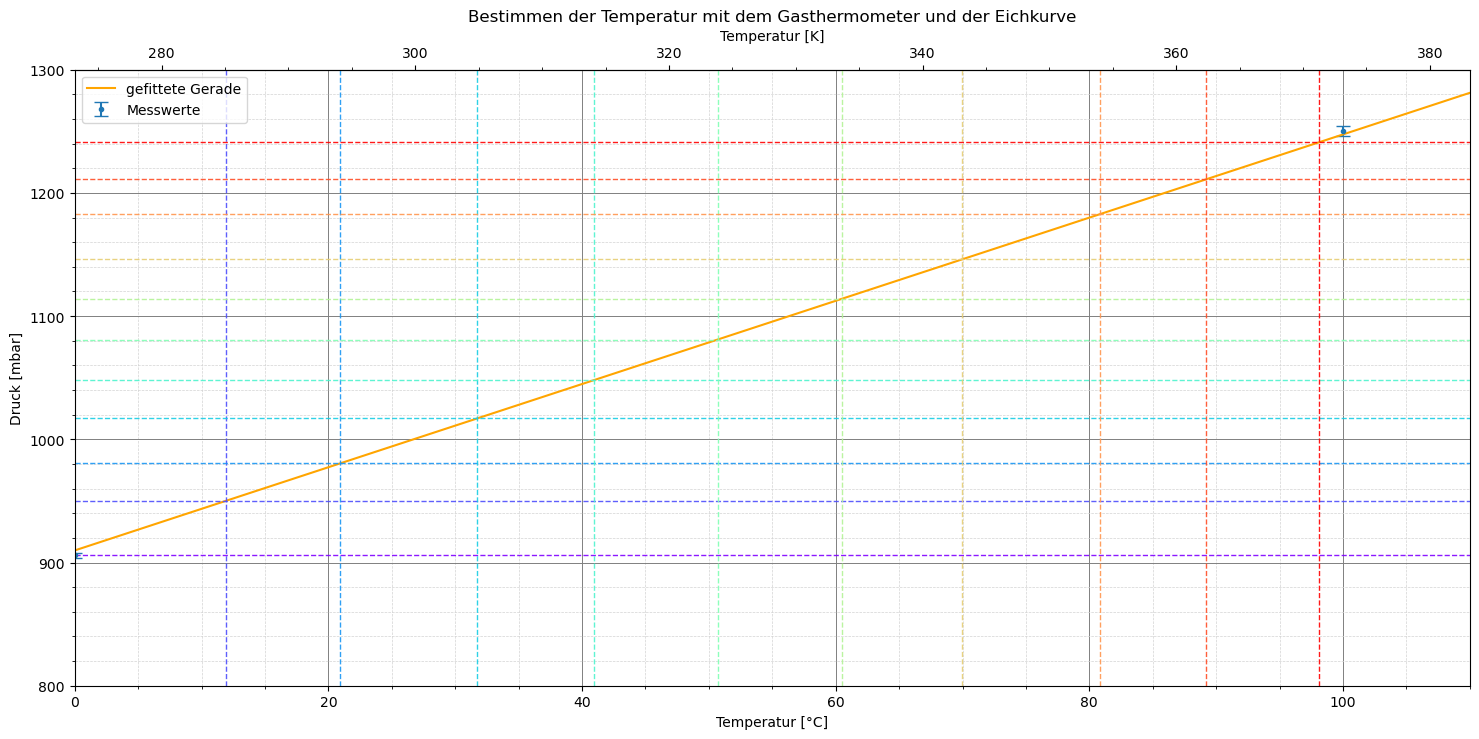

In [58]:
fig, ax = plt.subplots(figsize=(18, 8))

ax.errorbar(
    T_A2,
    p_A2,
    yerr=[p_stickstoff_error, p_0_error, p_100_error],
    fmt='.',
    capsize=5,
    label='Messwerte'
)

ax.plot(
    np.linspace(-280, 110, 100),
    func(np.linspace(-280, 110, 100), *popt_A2),
    label='gefittete Gerade',
    color='orange'
)

# rainbow markers for every nominal pressure/temperature pair
colors = plt.cm.rainbow(np.linspace(0, 1, len(pressure_values)))
for (p, T_nom), color in zip(zip(pressure_values, Temp_A3_values), colors):
    ax.axhline(p, color=color, linestyle='--', linewidth=1.0, alpha=0.9)
    ax.axvline(T_nom, color=color, linestyle='--', linewidth=1.0, alpha=0.9)

ax.set_title('Bestimmen der Temperatur mit dem Gasthermometer und der Eichkurve')
ax.set_xlabel('Temperatur [°C]')
ax.set_ylabel('Druck [mbar]')

ax.set_xlim(0, 110)
ax.set_ylim(800, 1300)

# Kelvin-Skala oben an der x-Achse
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x + 273.15, lambda x: x - 273.15))
ax2.set_xlabel('Temperatur [K]')
ax2.set_xlim(ax.get_xlim())

ax.minorticks_on()
ax2.minorticks_on()
ax.grid(which='major', linewidth=0.7, color='gray')
ax.grid(which='minor', linewidth=0.5, color='lightgray', linestyle='--')

ax.legend()


A4-Pt100

In [59]:
pt100_values = [99.8, 104.5, 108.1, 111.7, 115.5, 119.2, 123.0, 126.8, 130.8, 134.3, 137.9]

pt100 = unp.uarray(pt100_values, 0.08/100*np.array(pt100_values) + 0.2) 

len(pt100)

11

Text(0, 0.5, 'Widerstand des PT100-Sensors [Ohm]')

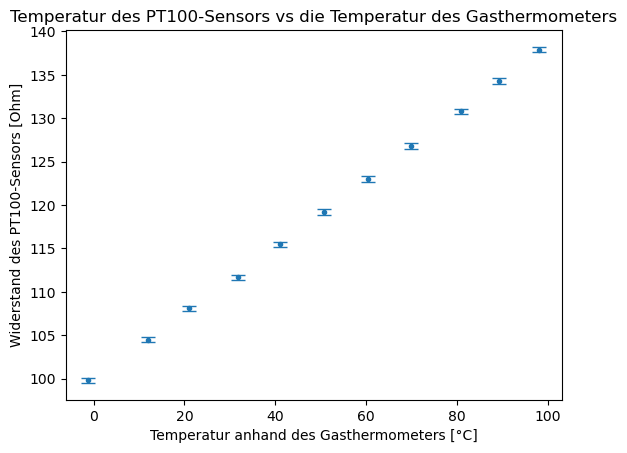

In [60]:
Temp_A4_values = Temp_A3_values


plt.errorbar(
    Temp_A4_values,
    unp.nominal_values(pt100),
    yerr=unp.std_devs(pt100),
    fmt='.',
    capsize=5,
    label='Messwerte'
)
plt.title('Temperatur des PT100-Sensors vs die Temperatur des Gasthermometers')
plt.xlabel('Temperatur anhand des Gasthermometers [°C]')
plt.ylabel('Widerstand des PT100-Sensors [Ohm]')




--> linearer fit 

In [61]:
func_pt100 = lambda T, m, c: m * T + c
popt_pt100, pcov_pt100 = curve_fit(func_pt100, Temp_A4_values, unp.nominal_values(pt100), sigma=unp.std_devs(pt100))

m_pt100, c_pt100 = popt_pt100
print(f"fitted func: R(T) = {m_pt100} * T + {c_pt100}")

error_m_pt100, error_c_pt100 = np.sqrt(np.diag(pcov_pt100))
print(f"Error in m, c: {error_m_pt100}, {error_c_pt100}")

print(pcov_pt100, pcov_pt100[0, 1], pcov_pt100[1, 0])

fitted func: R(T) = 0.3838269891444601 * T + 99.91962306196336
Error in m, c: 0.002310337944500579, 0.13276186768752105
[[ 5.33766142e-06 -2.57856169e-04]
 [-2.57856169e-04  1.76257135e-02]] -0.00025785616902153526 -0.00025785616902153526


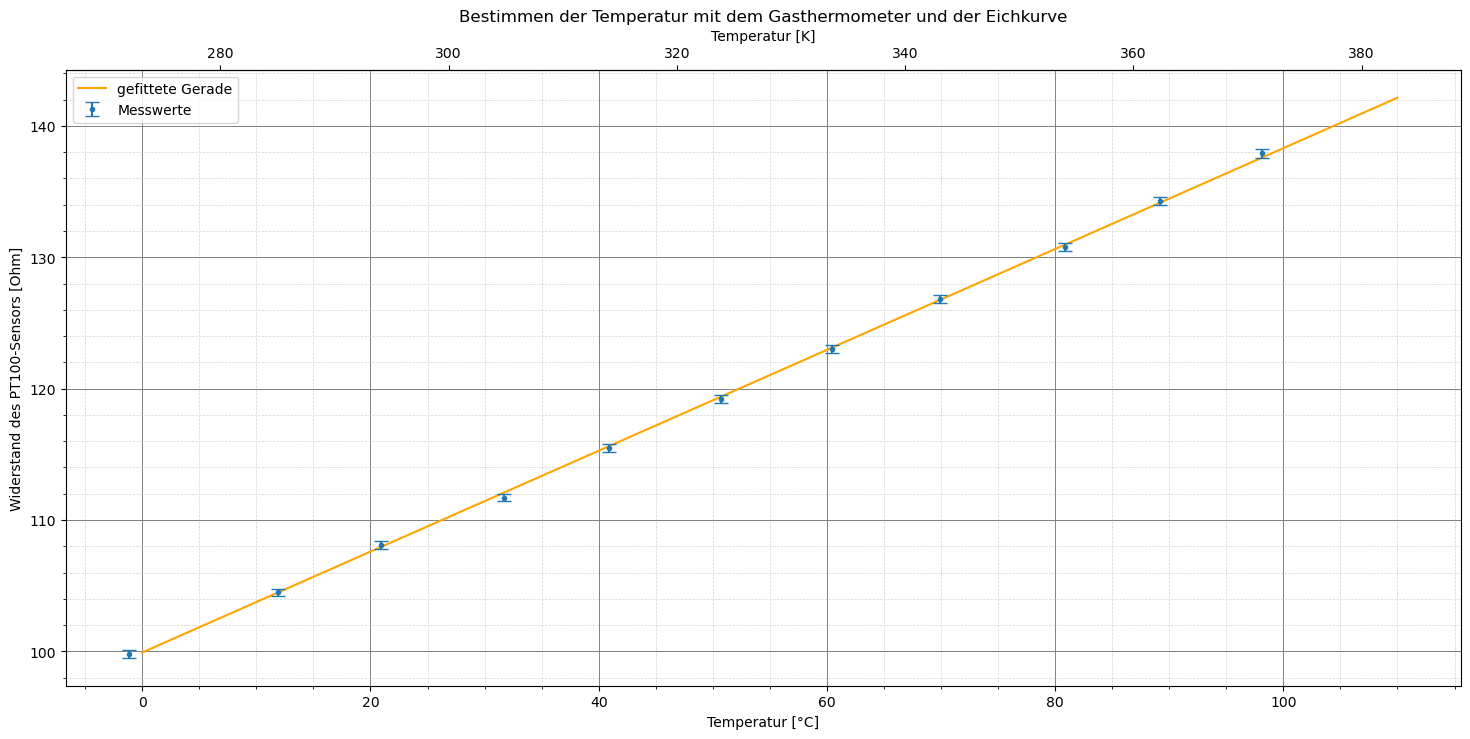

In [62]:
fig, ax = plt.subplots(figsize=(18, 8))



x_fit = np.linspace(0, 110, 100)
ax.plot(
    x_fit,
    func_pt100(x_fit, *popt_pt100),
    label='gefittete Gerade',
    color='orange'
)

ax.errorbar(
    Temp_A4_values,
    unp.nominal_values(pt100),
    yerr=unp.std_devs(pt100),
    fmt='.',
    capsize=5,
    label='Messwerte'
)


ax.set_title('Bestimmen der Temperatur mit dem Gasthermometer und der Eichkurve')
ax.set_xlabel('Temperatur [°C]')
ax.set_ylabel('Widerstand des PT100-Sensors [Ohm]')


ax2 = ax.secondary_xaxis('top', functions=(lambda x: x + 273.15, lambda x: x - 273.15))
ax2.set_xlabel('Temperatur [K]')

ax.minorticks_on()
ax.grid(which='major', linewidth=0.7, color='gray')
ax.grid(which='minor', linewidth=0.5, color='lightgray', linestyle='--')

ax.legend()


Pyrometer A5

In [63]:
Temp_pyro = np.array([-1, 9.3, 19.8, 29.9, 40.2, 48.5, 58.6, 67.9, 78.0, 84.0, 90.0])

unc_temp_pyro = unp.uarray(Temp_pyro, Temp_pyro * 0.015 + 2)
print(Temp_A3)
print('\n' + str(unc_temp_pyro))
type(Temp_A3)

[-1.1320048916483039+/-1.0463271448987546
 11.89932637036926+/-1.0492689264472357
 20.902791605945026+/-1.0554340572034604
 31.742489882986916+/-1.067245791779868
 40.923655090317475+/-1.0808912920109
 50.69715353683065+/-1.0989398638981294
 60.47065198334382+/-1.1204487175241686
 69.94798381026568+/-1.1444261708151038
 80.84691541122582+/-1.175551100481099
 89.19881408370073+/-1.2017980901395944
 98.08381267143997+/-1.2318395116246617]

[-1.0+/-1.985 9.3+/-2.1395 19.8+/-2.297 29.9+/-2.4485
 40.2+/-2.6029999999999998 48.5+/-2.7275 58.6+/-2.879 67.9+/-3.0185
 78.0+/-3.17 84.0+/-3.26 90.0+/-3.3499999999999996]


numpy.ndarray

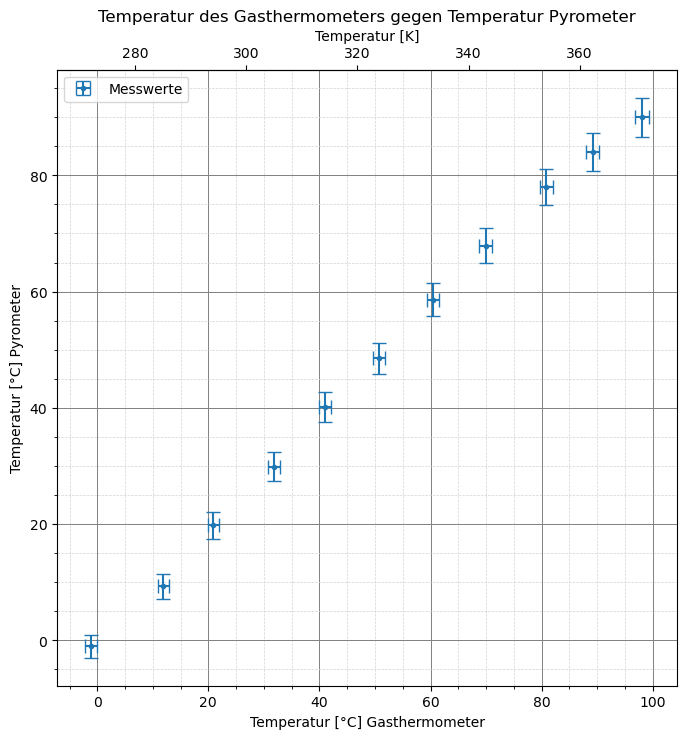

In [70]:
curve_fit_func = lambda T, m, c: m * T + c

popt_a5, pcov_a5 = curve_fit(
    curve_fit_func,
    unp.nominal_values(Temp_A3),
    unp.nominal_values(unc_temp_pyro),
    sigma=unp.std_devs(unc_temp_pyro),
    absolute_sigma=True
)

print(f"fitted func: T_pyro(T_gas) = {popt_a5[0]} * T_gas + {popt_a5[1]}")
Error_m_a5, Error_c_a5 = np.sqrt(np.diag(pcov_a5))
print(f"Error in m, c: {Error_m_a5}, {Error_c_a5}")

fitted func: T_pyro(T_gas) = 0.9534379589849825 * T_gas + -0.2398204413973506
Error in m, c: 0.025472355221219656, 1.2814418921174044


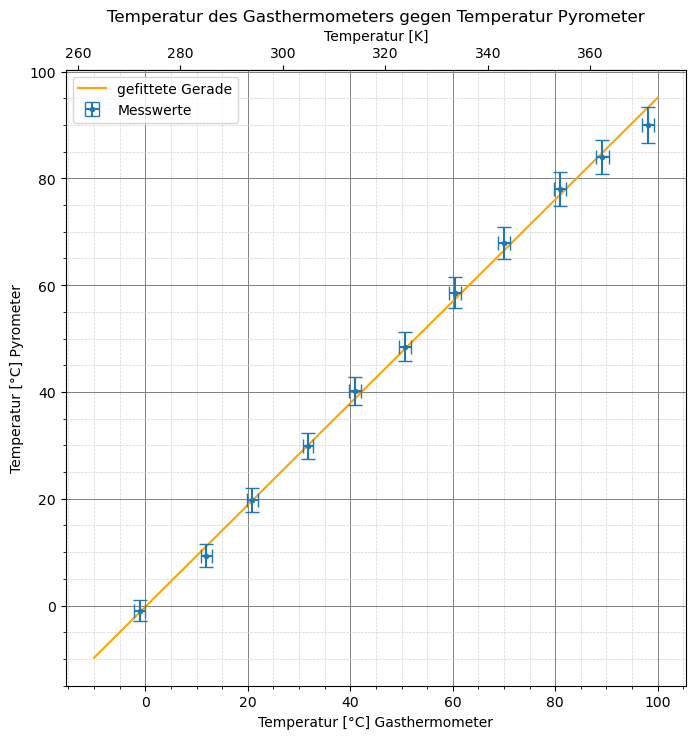

In [72]:
fig, ax = plt.subplots(figsize=(8, 8))


ax.plot(
    np.linspace(-10, 100, 100),
    curve_fit_func(np.linspace(-10, 100, 100), *popt_a5),
    label='gefittete Gerade',
    color='orange'
)


ax.errorbar(
    unp.nominal_values(Temp_A3),
    unp.nominal_values(unc_temp_pyro),
    xerr=unp.std_devs(Temp_A3),
    yerr=unp.std_devs(unc_temp_pyro),
    fmt='.',
    capsize=5,
    label='Messwerte'
)
# print(unp.std_devs(Temp_A3), unp.std_devs(unc_temp_pyro))

ax.set_title('Temperatur des Gasthermometers gegen Temperatur Pyrometer')
ax.set_xlabel('Temperatur [°C] Gasthermometer')
ax.set_ylabel('Temperatur [°C] Pyrometer')


ax2 = ax.secondary_xaxis('top', functions=(lambda x: x + 273.15, lambda x: x - 273.15))
ax2.set_xlabel('Temperatur [K]')

ax.minorticks_on()
ax.grid(which='major', linewidth=0.7, color='gray')
ax.grid(which='minor', linewidth=0.5, color='lightgray', linestyle='--')

ax.legend()
